# Boston SARS-CoV-2: EpiLink-Leiden and dated-tree TreeCluster

This notebook compares two clustering workflows on the same Boston SARS-CoV-2 samples.

| Workflow | Input | Clustering operation |
|---|---|---|
| **TreeCluster** | aligned consensus FASTA -> IQ-TREE -> TreeTime dated tree | tree cut over a time-threshold grid |
| **EpiLink-Leiden** | pairwise EpiLink compatibility scores | weighted graph clustered over a Leiden resolution grid |

The main output is a pair of heatmaps showing Adjusted Rand Index (ARI) and Adjusted
Mutual Information (AMI) for each Leiden resolution × TreeCluster threshold combination.
The notebook also exports a canonical Boston TreeCluster assignment using `avg_clade` at
28 days for downstream metadata joins.

## Setup and parameters

In [26]:
import io
import os
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

# Make the evaluation package and its bare-import modules importable.
SRC = Path("src").resolve()
for _p in (str(SRC), str(SRC / "evaluation")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from evaluation.config import (  # noqa: E402
    get_config_value,
    load_config,
    resolve_inference_baseline_parameters,
)
from evaluation.boston import add_temporal_distance  # noqa: E402
from evaluation.leiden import build_weighted_graph, run_leiden_partition  # noqa: E402
from evaluation.models import build_linkage_model  # noqa: E402
from evaluation.specs import DEFAULT_SEED  # noqa: E402
from evaluation.plotting import (  # noqa: E402
    PLOS_WIDTHS_CM,
    cm_to_inch,
    save_plos_figure,
    set_plos_theme,
    add_panel_labels,
)

In [28]:
# ---- inputs ----
ALN = "data/raw/boston/MGH_DPH_98percent_772samples_aligned.fasta"  # headers must match SAMPLE_COL
METADATA = "data/processed/boston/boston_metadata.parquet"
PAIRWISE = "data/processed/boston/boston_pairwise_distances.parquet"
SAMPLE_COL = "SeqID"  # sequence/sample names
DATE_COL = "Date"  # collection dates (YYYY-MM-DD, YYYY-MM, or decimal year)
PAIR_ID_1, PAIR_ID_2 = "SeqID1", "SeqID2"
GENETIC_COL = "SNP_Distance"

# ---- tree / dating parameters ----
OUTDIR = "phylo"
IQTREE_THREADS = "AUTO"
CLOCK_FILTER = 0  # drop tips > N IQDs off the clock; 0 disables
CLUSTER_METHOD = "avg_clade"
EXPORT_THRESHOLD_DAYS = 28.0

# ---- comparison grids ----
LEIDEN_RESOLUTIONS = np.round(np.arange(0.1, 1.01, 0.1), 2)  # EpiLink-Leiden (x-axis)
TC_THRESHOLD_DAYS = np.arange(7.0, 77.0, 7.0)  # TreeCluster (y-axis)

# ---- EpiLink / Leiden config (matched-baseline inference parameters) ----
config = load_config("config.yaml")
INFERENCE_PARAMS = resolve_inference_baseline_parameters(config)
MIN_EDGE_WEIGHT = float(
    get_config_value(config, "workflows.boston.minimum_edge_weight", default=0.0001)
)
N_RESTARTS = int(get_config_value(config, "workflows.boston.n_restarts", default=10))
WEIGHT_COL = "EpiLinkStochasticScore"
TEMPORAL_COL = "Temporal_Distance"

# ---- derived paths ----
os.makedirs(OUTDIR, exist_ok=True)
TREE = f"{OUTDIR}/boston_tree"
TREEFILE = f"{TREE}.treefile"
DATES = f"{OUTDIR}/dates.csv"
TT_DIR = f"{OUTDIR}/treetime"
TIMETREE_NEX = f"{TT_DIR}/timetree.nexus"
TIMETREE_NWK = f"{OUTDIR}/timetree.nwk"
CLUSTERS_TSV = f"{OUTDIR}/clusters.tsv"
METADATA_WITH_CLUSTERS_TSV = f"{OUTDIR}/metadata_with_clusters.tsv"

## Step 1 — Write TreeTime date metadata

TreeTime requires a `name,date` table whose names match the tree tip labels. This cell
extracts the Boston sample dates and writes `phylo/dates.csv`.

In [3]:
meta = pd.read_parquet(METADATA)
missing = [c for c in (SAMPLE_COL, DATE_COL) if c not in meta.columns]
assert not missing, f"Missing column(s) {missing}. Found: {meta.columns.tolist()}"

dates = meta[[SAMPLE_COL, DATE_COL]].dropna()
dates.columns = ["name", "date"]
dates.to_csv(DATES, index=False)
print(f"{len(dates)} dated samples written to {DATES}")
dates.head()

772 dated samples written to phylo/dates.csv


,name,date
0,MA_MGH_00003,2020-03-09
1,MA_MGH_00004,2020-03-11
2,MA_MGH_00005,2020-03-11
3,MA_MGH_00006,2020-03-11
4,MA_MGH_00013,2020-03-23


## Step 2 — Build the genetic tree with IQ-TREE

IQ-TREE infers a maximum-likelihood tree from the aligned Boston consensus genomes. The
resulting `.treefile` is the genetic tree used for TreeTime calibration.

In [ ]:
!iqtree -s {ALN} -m MFP -fast -T {IQTREE_THREADS} --prefix {TREE}
assert os.path.getsize(TREEFILE) > 0, "tree build failed — check the output above"
print("tree:", TREEFILE)

## Step 3 — Time-calibrate the tree with TreeTime

TreeTime estimates a molecular clock and rescales branch lengths into calendar years.
`CLOCK_FILTER = 0` keeps all tips; use a positive value to remove temporal outliers before
TreeCluster cutting.

In [ ]:
clock = f"--clock-filter {CLOCK_FILTER}" if CLOCK_FILTER else ""
!treetime --tree {TREEFILE} --aln {ALN} --dates {DATES} {clock} --outdir {TT_DIR} --stochastic-resolve
assert os.path.exists(TIMETREE_NEX), (
    "TreeTime produced no timetree — check output above"
)
print("dated tree:", TIMETREE_NEX)

### Temporal signal diagnostic

The root-to-tip regression summarizes whether the dated tree has usable temporal signal.
Weak signal means the TreeCluster time thresholds should be interpreted cautiously.

In [19]:
clk = os.path.join(TT_DIR, "molecular_clock.txt")
if os.path.exists(clk):
    print(open(clk).read())
reg = os.path.join(TT_DIR, "root_to_tip_regression.pdf")
print("Root-to-tip regression plot:", reg if os.path.exists(reg) else "(not found)")

Root-Tip-Regression:
 --rate:	6.783e-04
 --r^2:  	0.19


Root-to-tip regression plot: phylo/treetime/root_to_tip_regression.pdf


## Step 4 — Convert the dated tree to Newick

TreeTime writes the dated tree in NEXUS format, while TreeCluster reads Newick. `gotree`
performs the format conversion while preserving the year-scaled branch lengths.

In [ ]:
!gotree reformat newick -i {TIMETREE_NEX} -f nexus -o {TIMETREE_NWK}
assert os.path.getsize(TIMETREE_NWK) > 0, "nexus->newick conversion failed"
print("dated newick:", TIMETREE_NWK)

## Step 5 — Run TreeCluster over time thresholds

TreeCluster cuts the dated tree at each threshold in `TC_THRESHOLD_DAYS`; the command-line
threshold is expressed in years, so the notebook uses `days / 365`. TreeCluster labels
singletons as `-1`, which are handled explicitly during partition comparison.

The final block in this step writes the canonical Boston TreeCluster export:
`phylo/clusters.tsv` and `phylo/metadata_with_clusters.tsv`.

In [ ]:
def treecluster_frame(newick_path, threshold_years, method):
    # Run TreeCluster and return its SequenceName -> ClusterNumber table.
    proc = subprocess.run(
        [
            "TreeCluster.py",
            "-i",
            str(newick_path),
            "-t",
            str(threshold_years),
            "-m",
            method,
        ],
        capture_output=True,
        text=True,
        check=True,
    )
    df = pd.read_csv(io.StringIO(proc.stdout), sep="\t")
    df.columns = ["SequenceName", "ClusterNumber"]
    df["ClusterNumber"] = df["ClusterNumber"].astype(int)
    return df


def treecluster_partition(newick_path, threshold_years, method):
    # Return {SeqID: cluster_id} (-1 = singleton).
    df = treecluster_frame(newick_path, threshold_years, method)
    return dict(zip(df["SequenceName"], df["ClusterNumber"]))


treecluster_partitions = {}
for days in TC_THRESHOLD_DAYS:
    partition = treecluster_partition(TIMETREE_NWK, float(days) / 365.0, CLUSTER_METHOD)
    treecluster_partitions[float(days)] = partition
    n_clusters = len({c for c in partition.values() if c != -1})
    n_singletons = sum(1 for c in partition.values() if c == -1)
    print(f"{CLUSTER_METHOD} t={days:5.0f}d  {n_clusters:4d} clusters  {n_singletons:4d} singletons")

# Canonical Boston TreeCluster export at the selected threshold.
export_clusters = treecluster_frame(
    TIMETREE_NWK,
    EXPORT_THRESHOLD_DAYS / 365.0,
    CLUSTER_METHOD,
)
export_clusters.to_csv(CLUSTERS_TSV, sep="\t", index=False)

metadata_with_clusters = meta.merge(
    export_clusters,
    left_on=SAMPLE_COL,
    right_on="SequenceName",
    how="left",
)
metadata_with_clusters["ClusterNumber"] = (
    metadata_with_clusters["ClusterNumber"].fillna(-1).astype(int)
)
metadata_with_clusters.to_csv(METADATA_WITH_CLUSTERS_TSV, sep="\t", index=False)

n_clusters = int(export_clusters.loc[export_clusters["ClusterNumber"] != -1, "ClusterNumber"].nunique())
n_singletons = int((export_clusters["ClusterNumber"] == -1).sum())
print(
    f"exported {CLUSTERS_TSV} and {METADATA_WITH_CLUSTERS_TSV}: "
    f"{CLUSTER_METHOD} @ {EXPORT_THRESHOLD_DAYS:g}d, "
    f"{n_clusters} clusters, {n_singletons} singletons"
)

avg_clade t=    7d   102 clusters   491 singletons
avg_clade t=   14d   113 clusters   410 singletons
avg_clade t=   21d   113 clusters   295 singletons
avg_clade t=   28d   111 clusters   230 singletons
avg_clade t=   35d   108 clusters   156 singletons
avg_clade t=   42d    88 clusters    96 singletons
avg_clade t=   49d    72 clusters    76 singletons
avg_clade t=   56d    54 clusters    59 singletons
avg_clade t=   63d    48 clusters    28 singletons
avg_clade t=   70d    40 clusters    17 singletons
exported phylo/clusters.tsv and phylo/metadata_with_clusters.tsv: avg_clade @ 28d, 111 clusters, 230 singletons


## Step 6 — Run EpiLink-Leiden over resolutions

The matched-baseline stochastic EpiLink model scores each Boston pair from sampling-time
difference and SNP distance. Scores above the configured minimum weight form the graph
that is clustered by multi-restart Leiden across `LEIDEN_RESOLUTIONS`.

In [22]:
pair = pd.read_parquet(PAIRWISE)
pair = add_temporal_distance(
    pair, meta, SAMPLE_COL, PAIR_ID_1, PAIR_ID_2, DATE_COL, TEMPORAL_COL
)

model = build_linkage_model(
    INFERENCE_PARAMS, mutation_process="stochastic", rng_seed=DEFAULT_SEED
)
pair[WEIGHT_COL] = np.asarray(
    model.score_target(
        sample_time_difference=pair[TEMPORAL_COL].to_numpy(),
        genetic_distance=pair[GENETIC_COL].to_numpy(),
    ),
    dtype=float,
)

all_ids = pd.unique(pair[[PAIR_ID_1, PAIR_ID_2]].values.ravel())
graph = build_weighted_graph(
    minimum_weight=MIN_EDGE_WEIGHT,
    pairwise_frame=pair,
    weight_column=WEIGHT_COL,
    source_column=PAIR_ID_1,
    target_column=PAIR_ID_2,
    vertex_ids=all_ids,
)


def leiden_partition(resolution):
    # Run multi-restart Leiden and return {SeqID: cluster_id}.
    partition, _ = run_leiden_partition(
        graph,
        WEIGHT_COL,
        float(resolution),
        num_restarts=N_RESTARTS,
        rng_seed=DEFAULT_SEED,
    )
    return {
        graph.vs[i]["case_id"]: partition.membership[i] for i in range(graph.vcount())
    }


leiden_partitions = {}
for resolution in LEIDEN_RESOLUTIONS:
    partition = leiden_partition(resolution)
    leiden_partitions[float(resolution)] = partition
    print(f"resolution={resolution:.1f}  {len(set(partition.values())):4d} clusters")

resolution=0.1   134 clusters
resolution=0.2   175 clusters
resolution=0.3   208 clusters
resolution=0.4   238 clusters
resolution=0.5   306 clusters
resolution=0.6   411 clusters
resolution=0.7   527 clusters
resolution=0.8   670 clusters
resolution=0.9   772 clusters
resolution=1.0   772 clusters


## Step 7 — Compare partitions with ARI and AMI

For every Leiden resolution and TreeCluster threshold, the notebook compares the two hard
partitions over their shared samples.

- **ARI** is chance-corrected and based on pair co-membership.
- **AMI** is chance-corrected and based on shared information between labelings.

TreeCluster `-1` singletons are converted to unique singleton labels so they are treated
consistently with Leiden's complete node labeling.

In [23]:
shared = sorted(
    set(all_ids).intersection(*[set(p) for p in treecluster_partitions.values()])
)
print(f"{len(shared)} samples shared by both methods")


def label_vector(partition):
    # Project {SeqID: cluster} onto `shared`; each -1 becomes a unique singleton label.
    labels = []
    singleton = 10**6
    for sample in shared:
        cluster = partition.get(sample, -1)
        if cluster == -1:
            labels.append(singleton)
            singleton += 1
        else:
            labels.append(cluster)
    return labels


leiden_labels = {res: label_vector(p) for res, p in leiden_partitions.items()}
index = [f"{d:g}" for d in TC_THRESHOLD_DAYS]
columns = [f"{r:g}" for r in LEIDEN_RESOLUTIONS]
ari = pd.DataFrame(index=index, columns=columns, dtype=float)
ami = pd.DataFrame(index=index, columns=columns, dtype=float)

for days, tc_partition in treecluster_partitions.items():
    tc_labels = label_vector(tc_partition)
    for res in LEIDEN_RESOLUTIONS:
        ari.loc[f"{days:g}", f"{res:g}"] = adjusted_rand_score(
            tc_labels, leiden_labels[float(res)]
        )
        ami.loc[f"{days:g}", f"{res:g}"] = adjusted_mutual_info_score(
            tc_labels, leiden_labels[float(res)]
        )

ari.to_csv(f"{OUTDIR}/epilink_vs_treecluster_ari.csv")
ami.to_csv(f"{OUTDIR}/epilink_vs_treecluster_ami.csv")
print(
    "ARI range %.3f..%.3f | AMI range %.3f..%.3f"
    % (
        ari.to_numpy().min(),
        ari.to_numpy().max(),
        ami.to_numpy().min(),
        ami.to_numpy().max(),
    )
)
ami

772 samples shared by both methods
ARI range 0.000..0.553 | AMI range -0.000..0.599


,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1
7,0.201625,0.233749,0.264287,0.289645,0.271429,0.156333,0.053303,0.005343,-8.542374e-11,-8.542374e-11
14,0.277347,0.309659,0.337983,0.369425,0.348186,0.229988,0.105953,0.043507,-6.975366e-11,-6.975366e-11
21,0.404074,0.435791,0.472045,0.501483,0.482834,0.321322,0.161796,0.066026,-4.156719e-11,-4.156719e-11
28,0.478599,0.511246,0.548235,0.582224,0.564151,0.399043,0.208771,0.072554,-2.278646e-11,-2.278646e-11
35,0.526701,0.542217,0.573499,0.594937,0.557853,0.374317,0.193497,0.066943,-1.236936e-11,-1.236936e-11
42,0.565113,0.552965,0.570103,0.585105,0.541018,0.360929,0.193093,0.067312,1.903516e-12,1.903516e-12
49,0.581053,0.561813,0.576107,0.582753,0.531304,0.344003,0.183027,0.063185,6.801067e-12,6.801067e-12
56,0.577083,0.552502,0.553249,0.555775,0.501354,0.325850,0.178530,0.062596,4.621150e-12,4.621150e-12
63,0.582321,0.557203,0.548461,0.544991,0.488881,0.318629,0.175317,0.060581,1.581947e-12,1.581947e-12
70,0.598825,0.559887,0.545555,0.537216,0.478230,0.315064,0.176035,0.059753,9.450907e-13,9.450907e-13


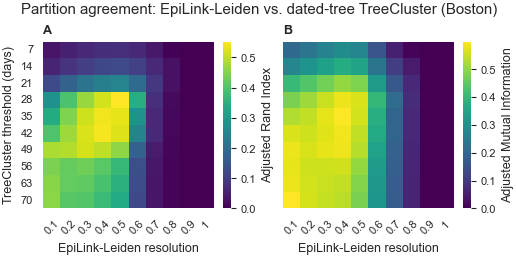

In [25]:
set_plos_theme()

fig, axes = plt.subplots(
    1, 2,
    figsize=(
        cm_to_inch(PLOS_WIDTHS_CM["text_column"]),
        cm_to_inch(PLOS_WIDTHS_CM["text_column"]) * 0.5,
    ),
    sharex=True,
    sharey=True,
    layout="constrained",
)

for ax, matrix, title in (
    (axes[0], ari, "Adjusted Rand Index"),
    (axes[1], ami, "Adjusted Mutual Information"),
):
    sns.heatmap(
        matrix,
        cmap="viridis",
        vmin=0,
        cbar_kws={"label": title},
        ax=ax,
    )
    ax.set_xlabel("EpiLink-Leiden resolution")

axes[0].set_ylabel("TreeCluster threshold (days)")
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)
for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="center")
    
fig.suptitle("Partition agreement: EpiLink-Leiden vs. dated-tree TreeCluster (Boston)")

add_panel_labels(axes)
_ = save_plos_figure(
    fig, 
    "epilink_vs_treecluster_similarity", 
    out_dir=OUTDIR,
    save_pdf=True,
    save_png=True,
    save_tiff=True,
    save_eps=False,
    )

## Notes and interpretation

- **Metric scope.** ARI and AMI compare EpiLink-Leiden and TreeCluster to each other; they
  do not score either method against an external Boston ground truth.
- **Threshold units.** TreeCluster operates on the dated tree in years, while heatmap rows
  are shown in days for readability.
- **Shared samples.** The comparison is restricted to samples present in both the EpiLink
  graph and the dated tree.
- **Canonical export.** `clusters.tsv` and `metadata_with_clusters.tsv` use `avg_clade` at
  28 days, matching the synthetic TreeCluster setting selected by BCubed F1.
- **EpiLink model.** The scoring model matches the stochastic Boston workflow implemented
  in `src/evaluation/boston.py`.